### Setup Environment & Instalasi Library

In [6]:
!pip install kagglehub pandas numpy matplotlib seaborn scikit-learn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Load Dataset from Kaggle
https://www.kaggle.com/datasets/prokshitha/home-value-insights

In [7]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "house_price_regression_dataset.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "prokshitha/home-value-insights",
  file_path,
  # Provide any additional arguments like 
  # sql_query or pandas_kwargs. See the 
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

print("First 5 records:", df.head())

/tmp/ipykernel_5671/3735774195.py:10: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


100%|██████████| 53.5k/53.5k [00:00<00:00, 6.42MB/s]

First 5 records:    Square_Footage  Num_Bedrooms  Num_Bathrooms  Year_Built  Lot_Size  \
0            1360             2              1        1981  0.599637   
1            4272             3              3        2016  4.753014   
2            3592             1              2        2016  3.634823   
3             966             1              2        1977  2.730667   
4            4926             2              1        1993  4.699073   

   Garage_Size  Neighborhood_Quality   House_Price  
0            0                     5  2.623829e+05  
1            1                     6  9.852609e+05  
2            0                     9  7.779774e+05  
3            1                     8  2.296989e+05  
4            0                     8  1.041741e+06  


### EDA (Exploratory Data Analysis)

In [8]:
# Data Profilling
print("Struktur Data")
print(df.info())

print("\nPengecekan Missing Value")
print(df.isnull().sum())

print("\nStatistik Deskriptif")
display(df.describe())


Struktur Data
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Square_Footage        1000 non-null   int64  
 1   Num_Bedrooms          1000 non-null   int64  
 2   Num_Bathrooms         1000 non-null   int64  
 3   Year_Built            1000 non-null   int64  
 4   Lot_Size              1000 non-null   float64
 5   Garage_Size           1000 non-null   int64  
 6   Neighborhood_Quality  1000 non-null   int64  
 7   House_Price           1000 non-null   float64
dtypes: float64(2), int64(6)
memory usage: 62.6 KB
None

Pengecekan Missing Value
Square_Footage          0
Num_Bedrooms            0
Num_Bathrooms           0
Year_Built              0
Lot_Size                0
Garage_Size             0
Neighborhood_Quality    0
House_Price             0
dtype: int64

Statistik Deskriptif


,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03
mean,2815.422000,2.990000,1.973000,1986.550000,2.778087,1.022000,5.615000,6.188610e+05
std,1255.514921,1.427564,0.820332,20.632916,1.297903,0.814973,2.887059,2.535681e+05
min,503.000000,1.000000,1.000000,1950.000000,0.506058,0.000000,1.000000,1.116269e+05
25%,1749.500000,2.000000,1.000000,1969.000000,1.665946,0.000000,3.000000,4.016482e+05
50%,2862.500000,3.000000,2.000000,1986.000000,2.809740,1.000000,6.000000,6.282673e+05
75%,3849.500000,4.000000,3.000000,2004.250000,3.923317,2.000000,8.000000,8.271413e+05
max,4999.000000,5.000000,3.000000,2022.000000,4.989303,2.000000,10.000000,1.108237e+06


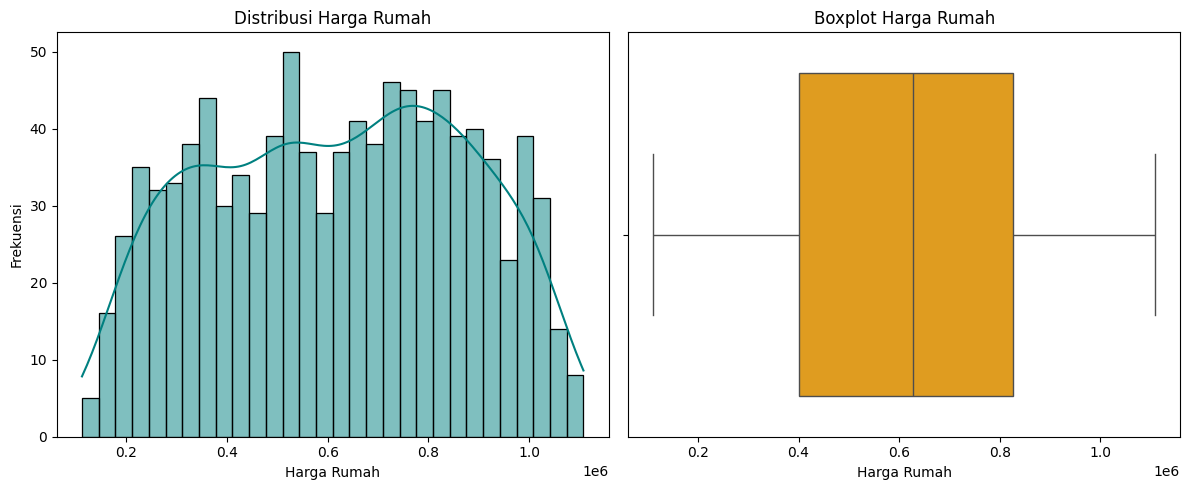

Statistik Deskriptif Target
count        1,000.00
mean       618,861.02
std        253,568.06
min        111,626.85
25%        401,648.23
50%        628,267.29
75%        827,141.28
max      1,108,236.84
Name: House_Price, dtype: object


In [ ]:
# Analisis Target Harga Rumah
plt.figure(figsize=(12, 5))

plt.subplot(1,2,1)
sns.histplot(data=df, x='House_Price', bins=30, kde=True, color='teal')
plt.title('Distribusi Harga Rumah')
plt.xlabel('Harga Rumah')
plt.ylabel('Frekuensi')

plt.subplot(1, 2, 2)
sns.boxplot(data=df, x='House_Price', color='orange')
plt.title('Boxplot Harga Rumah')
plt.xlabel('Harga Rumah')

plt.tight_layout()
plt.show()

print('Statistik Deskriptif Target')
print(df['House_Price'].describe().apply(lambda x: '{:,.2f}'.format(x)))

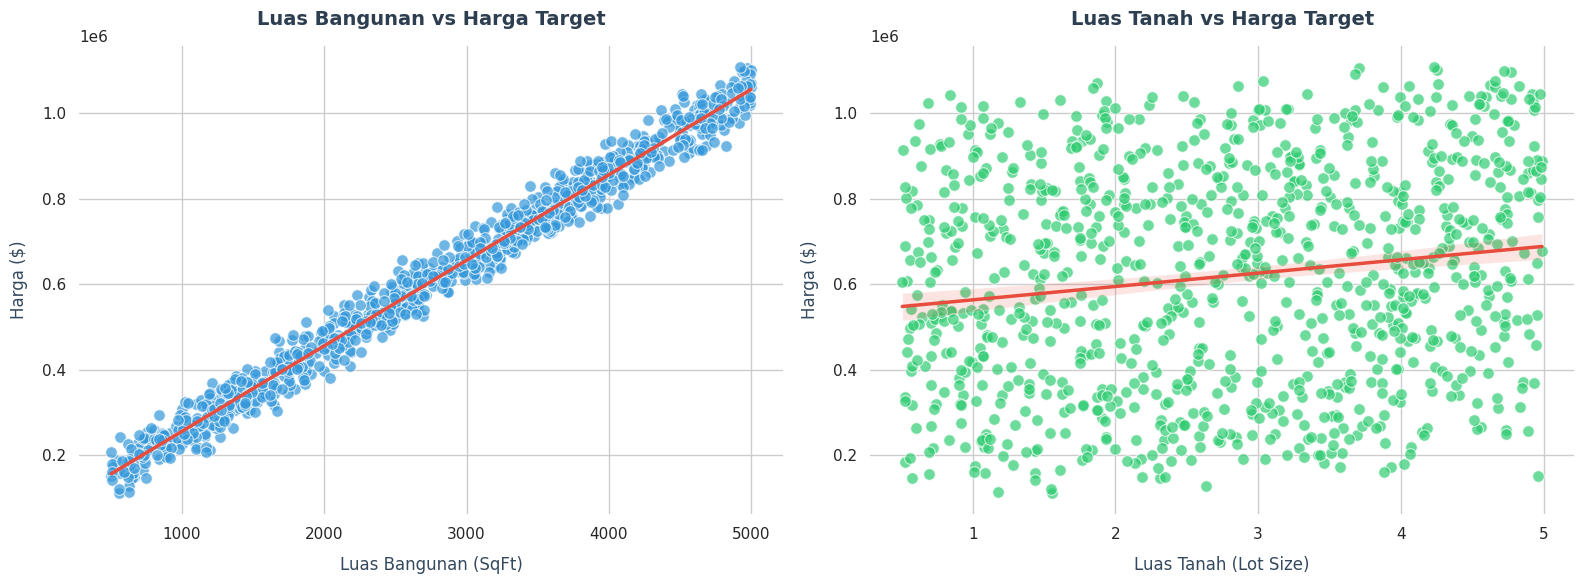

In [ ]:
# Analisis Dampak Luas Bangunan & Luas Tanah
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.scatterplot(
    data=df, x='Square_Footage', y='House_Price', 
    ax=axes[0],
    color='#3498db',     
    s=70,               
    edgecolor='white',   
    linewidth=0.8,
    alpha=0.7            
)

sns.regplot(data=df, x='Square_Footage', y='House_Price', ax=axes[0], scatter=False, color='#e74c3c', line_kws={"linewidth": 2.5})

axes[0].set_title('Luas Bangunan vs Harga Target', fontsize=14, pad=15, fontweight='bold', color='#2c3e50')
axes[0].set_xlabel('Luas Bangunan (SqFt)', fontsize=12, labelpad=10, color='#34495e')
axes[0].set_ylabel('Harga ($)', fontsize=12, labelpad=10, color='#34495e')

sns.scatterplot(
    data=df, x='Lot_Size', y='House_Price', 
    ax=axes[1],
    color='#2ecc71',     
    s=70,
    edgecolor='white',
    linewidth=0.8,
    alpha=0.7
)
sns.regplot(data=df, x='Lot_Size', y='House_Price', ax=axes[1], scatter=False, color='#e74c3c', line_kws={"linewidth": 2.5})

axes[1].set_title('Luas Tanah vs Harga Target', fontsize=14, pad=15, fontweight='bold', color='#2c3e50')
axes[1].set_xlabel('Luas Tanah (Lot Size)', fontsize=12, labelpad=10, color='#34495e')
axes[1].set_ylabel('Harga ($)', fontsize=12, labelpad=10, color='#34495e')

sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()


/tmp/ipykernel_5671/2615499634.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_5671/2615499634.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


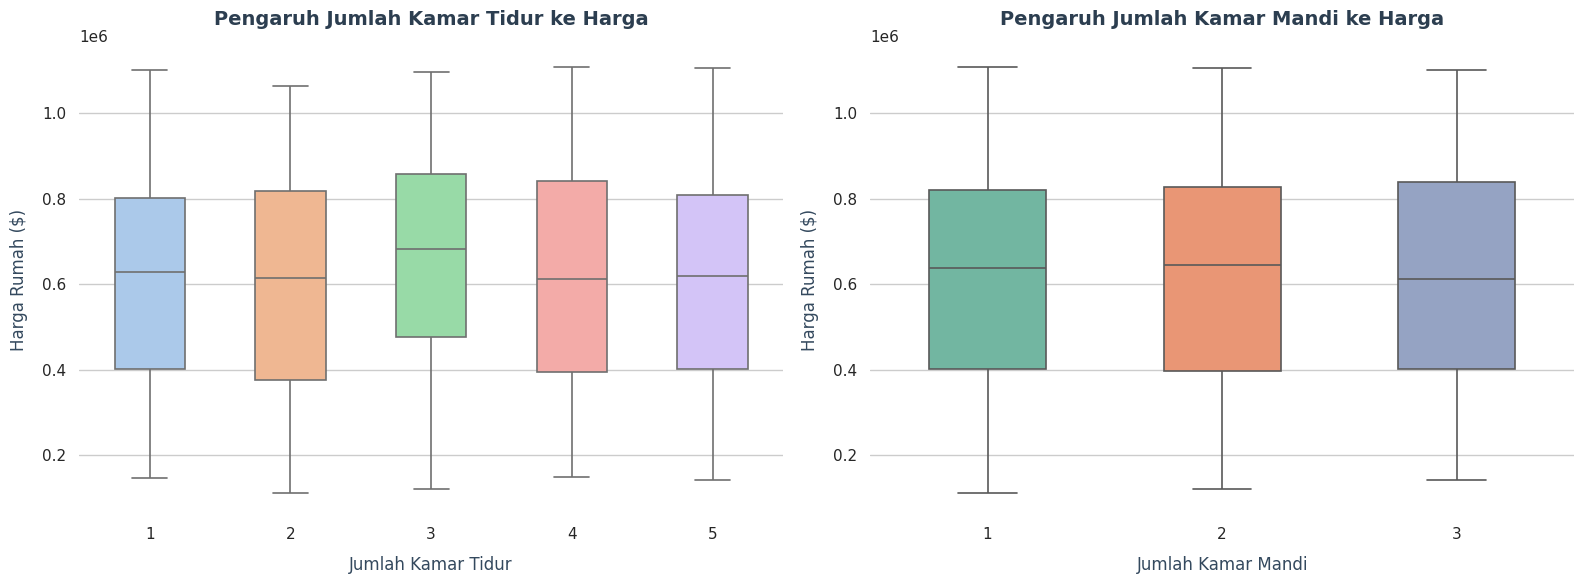

In [ ]:
# Analisis Dampak Jumlah Ruangan (Kamar Tidur & Kamar Mandi)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.boxplot(
    data=df, x='Num_Bedrooms', y='House_Price', 
    ax=axes[0],
    palette='pastel',      
    width=0.5,             
    linewidth=1.2,
    fliersize=4            
)

axes[0].set_title('Pengaruh Jumlah Kamar Tidur ke Harga', fontsize=14, pad=15, fontweight='bold', color='#2c3e50')
axes[0].set_xlabel('Jumlah Kamar Tidur', fontsize=12, labelpad=10, color='#34495e')
axes[0].set_ylabel('Harga Rumah ($)', fontsize=12, labelpad=10, color='#34495e')

sns.boxplot(
    data=df, x='Num_Bathrooms', y='House_Price', 
    ax=axes[1],
    palette='Set2',        
    width=0.5,
    linewidth=1.2,
    fliersize=4
)

axes[1].set_title('Pengaruh Jumlah Kamar Mandi ke Harga', fontsize=14, pad=15, fontweight='bold', color='#2c3e50')
axes[1].set_xlabel('Jumlah Kamar Mandi', fontsize=12, labelpad=10, color='#34495e')
axes[1].set_ylabel('Harga Rumah ($)', fontsize=12, labelpad=10, color='#34495e')

sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()


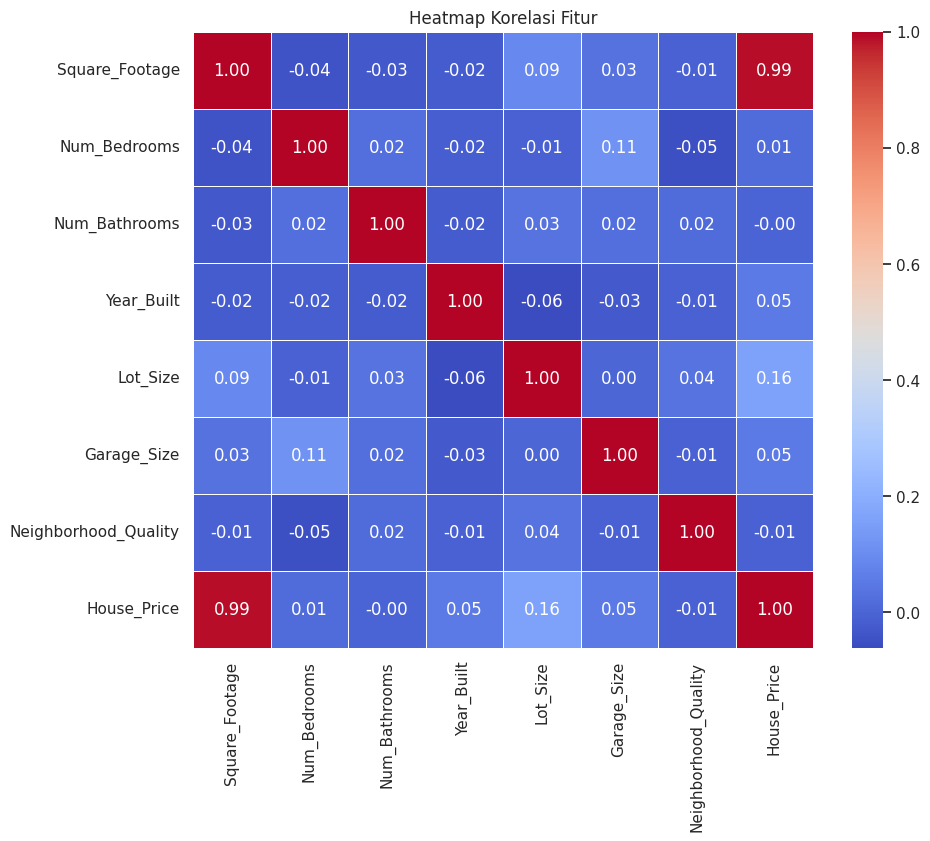

In [18]:
# Analisis Korelasi 
plt.figure(figsize=(10, 8))

corr_matrix = df[['Square_Footage', 'Num_Bedrooms', 'Num_Bathrooms', 'Year_Built', 'Lot_Size', 'Garage_Size', 'Neighborhood_Quality', 'House_Price']].corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Heatmap Korelasi Fitur')
plt.show()